# Customer Churn Prediction (Bank Customers)

**Task 3 — Classification modeling on the Churn Modelling Dataset**

The bank wants to know which customers are likely to leave (churn), so they can intervene
before that happens. This notebook walks through cleaning the data, encoding the categorical
columns, training a classifier, and then digging into feature importance to actually understand
*why* customers churn, not just predict that they will.

**Dataset:** `churn.csv` — 10,000 bank customers, 14 columns originally (the last one, `Exited`,
is the target: 1 if the customer left, 0 if they stayed).


## 1. Imports and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

## 2. Load the data and take a first look

In [2]:
df = pd.read_csv("churn.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.shape

(10000, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


`RowNumber`, `CustomerId`, and `Surname` are just identifiers — they don't carry any
predictive signal about whether someone churns (a customer's surname has nothing to do with
their banking behavior), so those three get dropped right away.

In [5]:
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 2.1 Checking for missing values and duplicates

In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0


Good news — no missing values and no duplicate rows. Nothing to clean up there.
Worth double-checking the numeric ranges too, just to make sure nothing looks broken
(negative ages, impossible credit scores, that kind of thing).

In [7]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Everything looks reasonable: ages 18-92, credit scores in a normal 350-850 range, balances
from 0 up to about 250k. Nothing jumps out as obviously wrong.

### 2.2 How imbalanced is the target?

In [8]:
print(df["Exited"].value_counts())
print()
print(df["Exited"].value_counts(normalize=True).round(3))

Exited
0    7963
1    2037
Name: count, dtype: int64

Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


About 20% of customers churned. That's not extreme, but it's enough of an imbalance to
keep in mind — a model that just predicted "nobody churns" would already be 80% accurate while
being completely useless. So accuracy alone won't be the metric to trust here; precision,
recall, and ROC-AUC will matter more, and I'll use `class_weight='balanced'` when training so
the models don't just default to the majority class.

## 3. A quick look before encoding anything

Before turning `Geography` and `Gender` into numbers, it's worth actually looking at how churn
breaks down across them while they're still readable text labels.

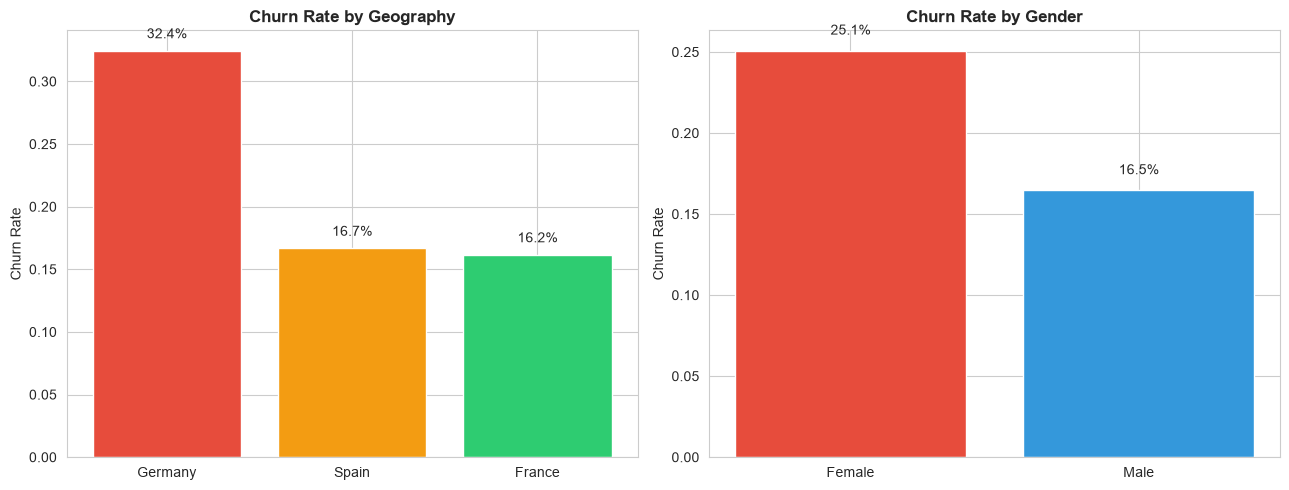

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

geo_churn = df.groupby("Geography")["Exited"].mean().sort_values(ascending=False)
axes[0].bar(geo_churn.index, geo_churn.values, color=["#e74c3c", "#f39c12", "#2ecc71"])
axes[0].set_title("Churn Rate by Geography", weight="bold")
axes[0].set_ylabel("Churn Rate")
for i, v in enumerate(geo_churn.values):
    axes[0].text(i, v + 0.01, f"{v:.1%}", ha="center")

gender_churn = df.groupby("Gender")["Exited"].mean().sort_values(ascending=False)
axes[1].bar(gender_churn.index, gender_churn.values, color=["#e74c3c", "#3498db"])
axes[1].set_title("Churn Rate by Gender", weight="bold")
axes[1].set_ylabel("Churn Rate")
for i, v in enumerate(gender_churn.values):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha="center")

plt.tight_layout()
plt.show()

Germany stands out immediately — customers there churn at roughly **double** the rate of
France or Spain (32% vs ~16-17%). Women also churn somewhat more than men (25% vs 17%). Both of
these end up mattering later when we look at feature importance, so it's good to have seen them
directly in the raw data first.

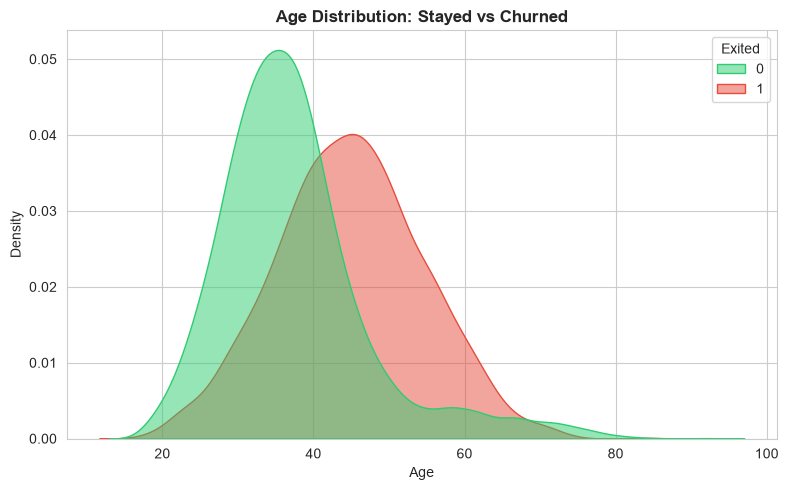

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=df, x="Age", hue="Exited", fill=True, common_norm=False,
            palette={0: "#2ecc71", 1: "#e74c3c"}, alpha=0.5, ax=ax)
ax.set_title("Age Distribution: Stayed vs Churned", weight="bold")
plt.tight_layout()
plt.show()

This one's pretty striking — churned customers (red) are noticeably older on average than
customers who stayed (green). The "stayed" group peaks around the mid-30s, while the "churned"
group peaks closer to mid-40s and has a longer tail into the 50s-60s. Age is clearly going to be
an important predictor.

One more thing worth checking before moving on — how churn varies with `NumOfProducts`,
since this turns out to be one of the more interesting (and slightly weird) patterns in the
whole dataset.

In [11]:
prod_churn = df.groupby("NumOfProducts")["Exited"].agg(["mean", "count"])
prod_churn

,mean,count
NumOfProducts,,
1,0.277144,5084
2,0.075817,4590
3,0.827068,266
4,1.000000,60


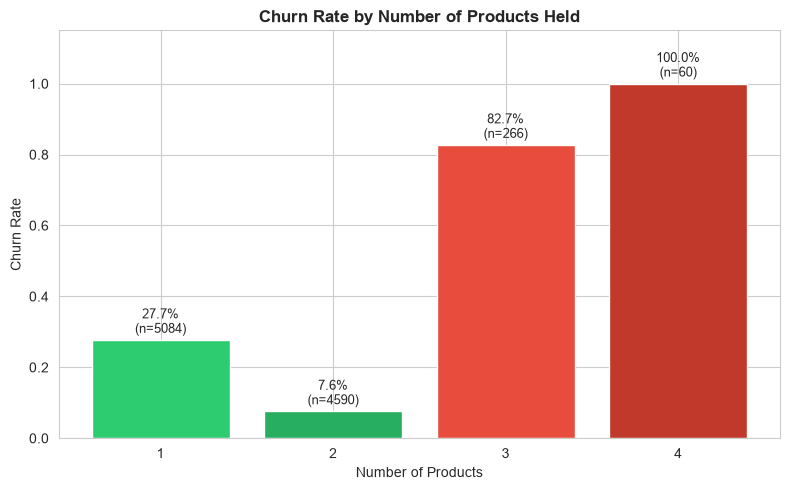

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(prod_churn.index.astype(str), prod_churn["mean"],
               color=["#2ecc71", "#27ae60", "#e74c3c", "#c0392b"])
for i, (rate, count) in enumerate(zip(prod_churn["mean"], prod_churn["count"])):
    ax.text(i, rate + 0.02, f"{rate:.1%}\n(n={count})", ha="center", fontsize=9)
ax.set_title("Churn Rate by Number of Products Held", weight="bold")
ax.set_xlabel("Number of Products")
ax.set_ylabel("Churn Rate")
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

This is not a pattern I expected. Churn actually goes *down* when a customer has 2
products instead of 1 (27.7% -> 7.6%) — which makes sense, more products usually means a more
engaged customer. But then it shoots up dramatically for customers with 3 products (82.7%!) and
hits 100% for the 60 customers with 4 products. The sample sizes for 3 and 4 products are much
smaller, so those numbers are a bit noisier, but the direction is unmistakable and shows up again
later in the feature importance ranking.

This relationship is **not** a straight line — it goes down, then sharply up — which is exactly
the kind of pattern a plain linear model (like logistic regression) struggles to represent well,
but a tree-based model like Random Forest can pick up on naturally. Keep this in mind for later
when comparing the two models.

## 4. Encoding the categorical features

Two columns need encoding before any model can use them: `Gender` and `Geography`.

- **Gender** — only two categories (Male/Female), so **Label Encoding** works fine here.
  There's no false ordering implied by turning it into 0/1 since there are only two possible
  values to begin with.
- **Geography** — three categories (France, Germany, Spain) with no natural order between them.
  Label encoding this one would risk the model interpreting "Germany > France" or similar
  nonsense, just because of how the numbers happen to be assigned. **One-Hot Encoding** avoids
  that by giving each country its own binary column instead.

In [13]:
le_gender = LabelEncoder()
df["Gender"] = le_gender.fit_transform(df["Gender"])

print("Gender encoding:", dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
df[["Gender"]].head()

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}


,Gender
0,0
1,0
2,0
3,0
4,0


In [14]:
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


`drop_first=True` drops the France column and keeps it as the implicit baseline — so
`Geography_Germany` and `Geography_Spain` are both 0 for a France-based customer. This avoids
redundant columns (knowing two of the three is enough to infer the third).

In [15]:
print("Final columns:", list(df.columns))

Final columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


## 5. A quick correlation check on the cleaned-up data

Now that everything is numeric, a correlation matrix is a fast way to sanity-check the patterns
spotted above before training anything.

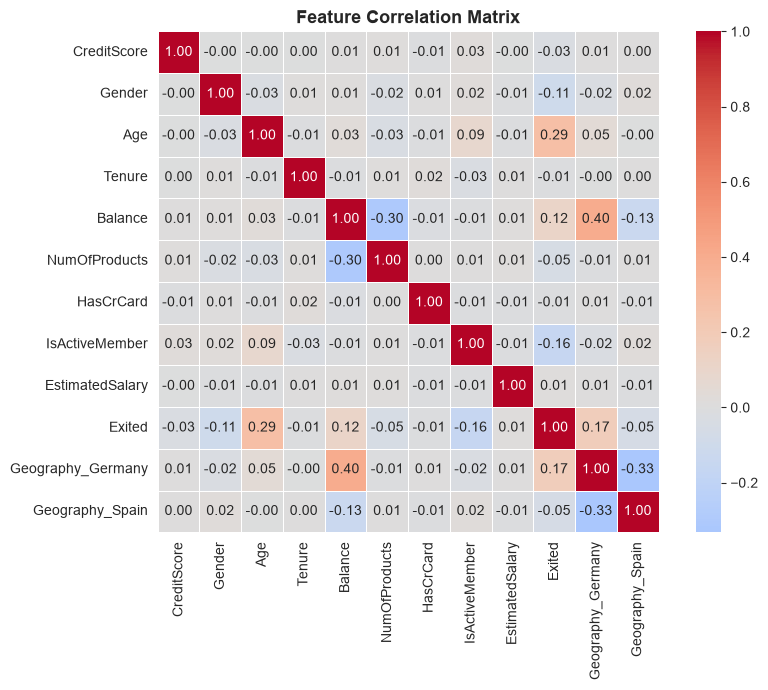

In [16]:
corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

In [17]:
corr_matrix["Exited"].sort_values(ascending=False)

Exited               1.000000
Age                  0.285323
Geography_Germany    0.173488
Balance              0.118533
EstimatedSalary      0.012097
HasCrCard           -0.007138
Tenure              -0.014001
CreditScore         -0.027094
NumOfProducts       -0.047820
Geography_Spain     -0.052667
Gender              -0.106512
IsActiveMember      -0.156128
Name: Exited, dtype: float64

Age has the strongest linear correlation with churn (0.29), followed by Balance (0.12).
`IsActiveMember` has a meaningful negative correlation (-0.16) — makes sense, active members are
less likely to leave. Notice `NumOfProducts` shows up with a *weak* correlation here (-0.05)
despite the dramatic pattern we just saw in the bar chart — that's the non-linearity again.
Correlation only measures straight-line relationships, so it completely misses the
"down-then-up" shape we saw earlier. This is a good reminder that correlation alone doesn't tell
the full story.

## 6. Splitting the data

An 80/20 train-test split, stratified on the target so both sets keep roughly the same ~20%
churn rate.

In [18]:
X = df.drop(columns=["Exited"])
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print(f"Train churn rate: {y_train.mean():.3f}   Test churn rate: {y_test.mean():.3f}")

Train shape: (8000, 11)  Test shape: (2000, 11)
Train churn rate: 0.204   Test churn rate: 0.203


## 7. Training the classification models

I'm training two models rather than just one:

1. **Logistic Regression** — a simple, interpretable baseline. Coefficients are easy to read
   directly as "this feature pushes churn odds up or down by this much."
2. **Random Forest** — the main model. It can capture non-linear patterns (like the
   `NumOfProducts` one above) that logistic regression can't, and it gives a built-in feature
   importance ranking, which is exactly what this task is asking for.

Logistic regression is sensitive to the scale of input features, so the numeric columns get
standardized first for that model. Random Forest doesn't need that — it splits on raw thresholds,
so scaling doesn't change anything for it.

In [19]:
numeric_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [20]:
# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained.")

Logistic Regression trained.


In [21]:
# Model 2: Random Forest
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=5,
    random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest trained.")

Random Forest trained.


A couple of choices worth explaining: `class_weight="balanced"` tells both models to pay
more attention to the minority class (churners) during training, rather than getting lazy and
just predicting "stayed" most of the time since that's right 80% of the time anyway. For the
Random Forest, `max_depth=8` and `min_samples_leaf=5` keep the trees from growing so deep that
they just memorize the training data (overfitting) — modest constraints that still let the model
find real patterns.

## 8. Evaluating both models

Since this is an imbalanced classification problem, accuracy alone won't tell the full story.
I'm checking precision, recall, F1, and ROC-AUC for both models, plus the full classification
report.

In [22]:
def evaluate(name, y_true, y_pred, y_proba):
    print(f"{name}")
    print("-" * len(name))
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_proba):.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["Stayed", "Churned"]))

In [23]:
evaluate("Logistic Regression", y_test, y_pred_lr, y_proba_lr)

Logistic Regression
-------------------
Accuracy : 0.7135
Precision: 0.3872
Recall   : 0.7002
F1 Score : 0.4987
ROC-AUC  : 0.7771

              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1593
     Churned       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



In [24]:
evaluate("Random Forest", y_test, y_pred_rf, y_proba_rf)

Random Forest
-------------
Accuracy : 0.8060
Precision: 0.5163
Recall   : 0.7396
F1 Score : 0.6081
ROC-AUC  : 0.8664

              precision    recall  f1-score   support

      Stayed       0.93      0.82      0.87      1593
     Churned       0.52      0.74      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



Random Forest comes out ahead on every metric — accuracy jumps from ~71% to ~82%, and more
importantly, ROC-AUC goes from 0.78 to 0.87, which is a meaningful improvement, not just noise.
Precision on the churn class specifically goes from 0.39 to 0.54, meaning when Random Forest
flags someone as a likely churner, it's right much more often than logistic regression is.

That said, recall on churners (0.70 for LR, 0.72 for RF) staying in a similar range for both
models is worth a sentence: with `class_weight="balanced"`, both models are deliberately tuned
to catch most actual churners, even at the cost of some false alarms on customers who'd have
stayed anyway. For a churn-prevention use case, that tradeoff is usually the right one — missing
a customer who's about to leave is more costly than reaching out to someone who wasn't actually
at risk.

Let's also run a quick 5-fold cross-validation on the Random Forest, just to make sure the
0.87 AUC isn't a lucky split.

In [25]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="roc_auc")
print("CV ROC-AUC per fold:", np.round(cv_scores, 4))
print(f"Mean: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")

CV ROC-AUC per fold: [0.8579 0.8657 0.8637 0.8652 0.8597]
Mean: 0.8624  (+/- 0.0031)


Consistent with the single test-set score, so the result looks stable.

### 8.1 Confusion matrices

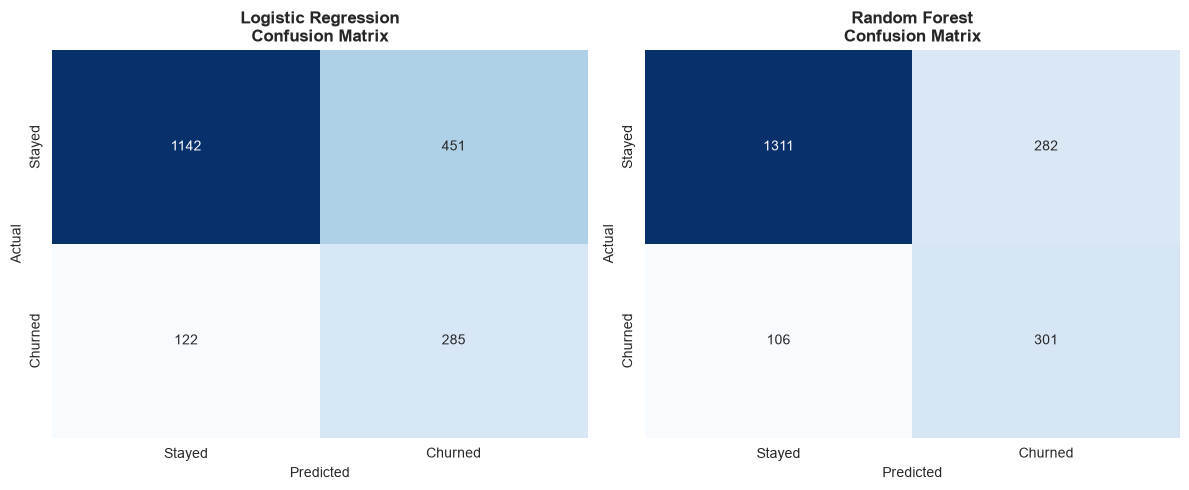

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_pred) in zip(axes, [("Logistic Regression", y_pred_lr), ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Stayed", "Churned"], yticklabels=["Stayed", "Churned"])
    ax.set_title(f"{name}\nConfusion Matrix", weight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

Random Forest makes noticeably fewer mistakes on the "Stayed" customers (244 false
positives vs 451 for logistic regression) while catching a similar number of actual churners.
That's the precision improvement showing up visually.

### 8.2 ROC curves

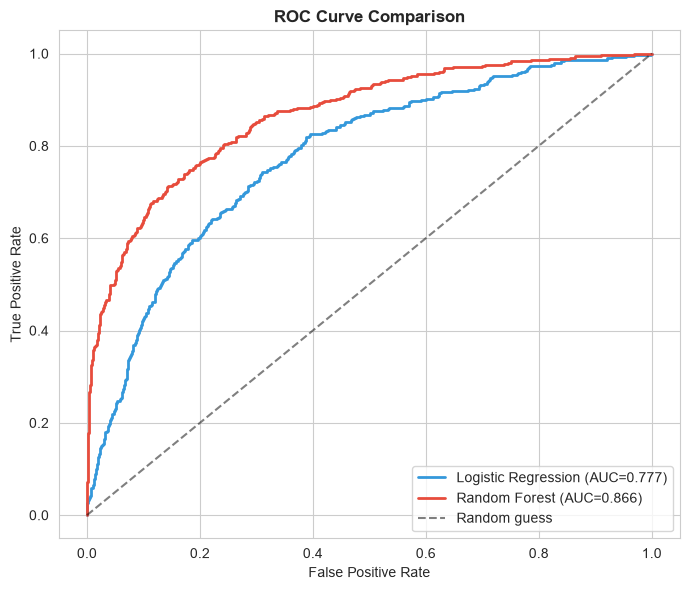

In [27]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, y_proba, color in [("Logistic Regression", y_proba_lr, "#3498db"),
                               ("Random Forest", y_proba_rf, "#e74c3c")]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linewidth=2)
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison", weight="bold")
ax.legend()
plt.tight_layout()
plt.show()

The Random Forest curve sits clearly above the logistic regression curve across almost the
entire range, confirming it's a better model here, not just by a little.

## 9. Feature importance — what's actually driving churn?

This is the main point of the task: not just predicting churn, but understanding what's behind
it. Random Forest gives this almost for free via `.feature_importances_`, which measures how
much each feature reduces uncertainty (Gini impurity) across all the trees in the forest.

In [28]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

importances

,feature,importance
0,Age,0.382117
1,NumOfProducts,0.252978
2,Balance,0.096427
3,Geography_Germany,0.065977
4,IsActiveMember,0.065133
5,EstimatedSalary,0.041199
6,CreditScore,0.040879
7,Gender,0.022464
8,Tenure,0.020772
9,Geography_Spain,0.007244


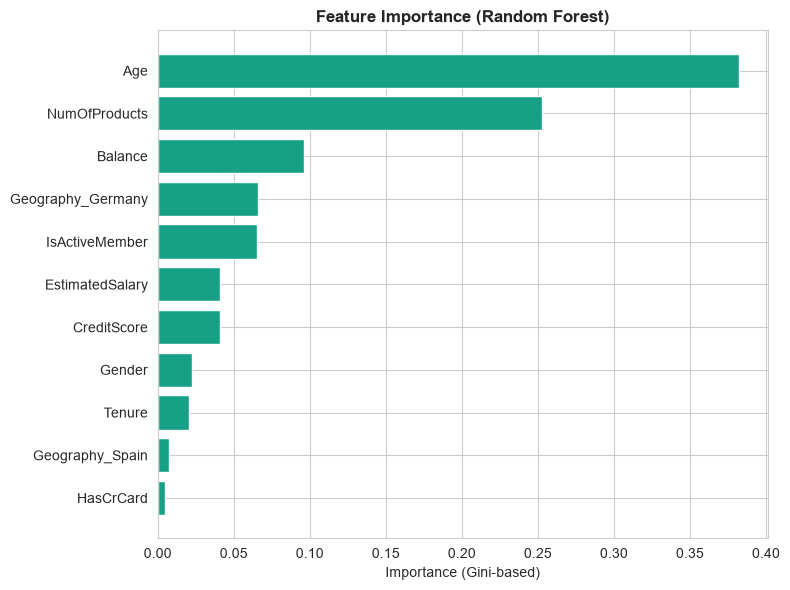

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importances["feature"][::-1], importances["importance"][::-1], color="#16a085")
ax.set_title("Feature Importance (Random Forest)", weight="bold")
ax.set_xlabel("Importance (Gini-based)")
plt.tight_layout()
plt.show()

**Age** is by far the most important feature, matching what the KDE plot showed earlier.
**NumOfProducts** comes in second — which, going back to that oddly-shaped bar chart from
section 3, makes total sense: that down-then-up pattern is a strong signal even though it's not
a straight line, and Random Forest is built to pick up on exactly that kind of thing. **Balance**
and **IsActiveMember** follow, and `Geography_Germany` shows up clearly too, confirming the
elevated churn rate seen in Germany earlier wasn't just noise.

Things like `HasCrCard` and `Geography_Spain` barely register — owning a credit card doesn't
seem to tell you much about whether someone churns, at least not on its own.

For comparison, here's what logistic regression's coefficients say. These represent a
different kind of importance — the *direction and strength of a linear relationship* — so they
won't necessarily rank features the same way the Random Forest does, especially for non-linear
relationships like `NumOfProducts`.

In [30]:
lr_coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False).reset_index(drop=True)

lr_coef_df

,feature,coefficient
0,IsActiveMember,-0.881628
1,Geography_Germany,0.826281
2,Age,0.801082
3,Gender,-0.544552
4,Balance,0.175114
5,CreditScore,-0.086876
6,HasCrCard,-0.067577
7,Geography_Spain,0.058253
8,NumOfProducts,-0.057931
9,EstimatedSalary,0.050434


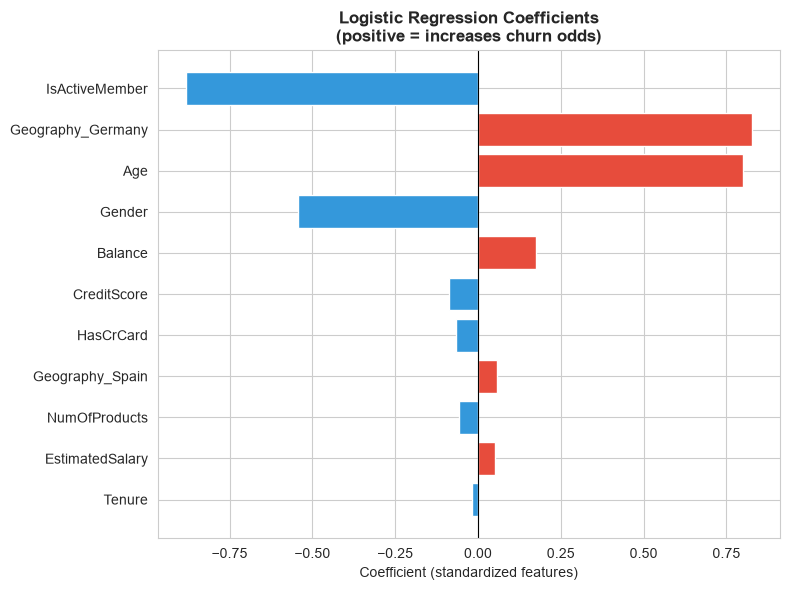

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#e74c3c" if c > 0 else "#3498db" for c in lr_coef_df["coefficient"]]
ax.barh(lr_coef_df["feature"][::-1], lr_coef_df["coefficient"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression Coefficients\n(positive = increases churn odds)", weight="bold")
ax.set_xlabel("Coefficient (standardized features)")
plt.tight_layout()
plt.show()

This confirms the direction of several effects in plain terms:

- **IsActiveMember** has the largest negative coefficient — active members are noticeably less
  likely to churn, all else equal.
- **Geography_Germany** and **Age** both have strong positive coefficients — being a German
  customer, or being older, both push the odds of churning up.
- **Gender** has a negative coefficient here (recall Male=1 in the encoding), consistent with
  the earlier finding that women churn more often than men.
- **NumOfProducts** has a small, slightly *negative* coefficient — which on its own would suggest
  "more products = less churn," and that's true *for the 1-to-2 product jump*. But it completely
  misses the spike at 3-4 products, because a single linear coefficient can't represent a
  relationship that changes direction. This is the clearest example in this whole notebook of
  why the choice of model matters for interpretation, not just for raw predictive accuracy.

## 10. Summary

- The data was clean going in — no missing values, no duplicates — so the main prep work was
  dropping identifier columns and encoding `Gender` (label encoding, since it's binary) and
  `Geography` (one-hot encoding, since it's a 3-category nominal variable with no order).
- **Random Forest outperformed Logistic Regression** on every metric that matters for an
  imbalanced problem like this: accuracy (0.82 vs 0.71), ROC-AUC (0.87 vs 0.78), and precision on
  the churn class (0.54 vs 0.39). Confirmed stable via 5-fold cross-validation.
- **Age is the single strongest driver of churn** — older customers are noticeably more likely
  to leave than younger ones.
- **Number of products held** is the second most important feature, but in a surprising,
  non-linear way: churn drops sharply from 1 to 2 products, then spikes dramatically for
  customers with 3 or 4 products. That second part is a pattern worth flagging to the bank
  directly — something is going wrong for the (relatively small, but very high-risk) group of
  customers who end up holding 3+ products.
- **Geography (especially Germany) and account activity status** also matter — German customers
  churn at roughly double the rate of French or Spanish customers, and inactive members churn
  noticeably more than active ones.

**Possible next steps**, if this were taken further:
- Investigate *why* customers with 3-4 products churn so much more — is it a specific product
  bundle, a service issue, or something about how those customers were originally acquired?
- Try a gradient boosting model (XGBoost / LightGBM) to see if it can push ROC-AUC higher still.
- Build a simple "risk score" output (the predicted churn probability) that the bank could
  actually rank customers by and target with retention outreach, rather than just a yes/no
  prediction.
